MT Project

Project Overview

The goal of this project is to develop a machine learning model that predicts the need for Massive Transfusion (MT) in traume patients during the early stages of hospital admission.

The model will be trained using clinical and laboratory parameters available upon arrival, including Shock Index, Lactate, Base Excess and Mechanism of Injury.

The target variable is Massive Transfusion status (Yes/No). Th final objective is to support early clinical desicion-making and improve the identification of patients at high risk of severe hemorrhage.


In [4]:
import pandas as pd 
import numpy as np 

import requests
from io import BytesIO


import matplotlib.pyplot as plt 
import seaborn as sns 

from pathlib import Path 
print ("Environment loaded successfully")

Environment loaded successfully


In [5]:
# Connect to dataset:

url = "https://raw.githubusercontent.com/Yuliana-wein/Predict-Massive-Transfusion-in-Trauma-PatieUsing-Early-Clinical-Parameters/main/Dataset/CRASH2_Final_Dataset.xlsx"

response = requests.get(url)
df = pd.read_excel(BytesIO(response.content))
df.head()

,Patient_ID,Age,Sex,Systolic_BP_mmHg,Heart_Rate_BPM,Respiratory_Rate_BPM,GCS_Score,Injury_Type,Units_Transfused,Lactate_mmol_L,Arterial_Base_Excess,Time_to_Hospital_min,Shock_Index,MT
0,PT-0001,66,Male,128,61,21,13,Blunt,0,1.6,0.6,111,0.48,0
1,PT-0002,43,Male,163,79,15,12,Blunt,1,1.2,0.8,75,0.48,0
2,PT-0003,80,Male,141,70,18,11,Blunt,1,4.0,-4.7,52,0.50,0
3,PT-0004,37,Male,100,86,10,13,Blunt,2,1.6,-4.0,40,0.86,0
4,PT-0005,72,Female,128,74,18,13,Blunt,0,0.8,-1.3,64,0.58,0


In [6]:
# Dataset size:
df.shape

(1000, 14)

In [7]:
# Data type info:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Patient_ID            1000 non-null   str    
 1   Age                   1000 non-null   int64  
 2   Sex                   1000 non-null   str    
 3   Systolic_BP_mmHg      1000 non-null   int64  
 4   Heart_Rate_BPM        1000 non-null   int64  
 5   Respiratory_Rate_BPM  1000 non-null   int64  
 6   GCS_Score             1000 non-null   int64  
 7   Injury_Type           1000 non-null   str    
 8   Units_Transfused      1000 non-null   int64  
 9   Lactate_mmol_L        1000 non-null   float64
 10  Arterial_Base_Excess  1000 non-null   float64
 11  Time_to_Hospital_min  1000 non-null   int64  
 12  Shock_Index           1000 non-null   float64
 13  MT                    1000 non-null   int64  
dtypes: float64(3), int64(8), str(3)
memory usage: 109.5 KB


In [8]:
# Statistics:
df.describe()

,Age,Systolic_BP_mmHg,Heart_Rate_BPM,Respiratory_Rate_BPM,GCS_Score,Units_Transfused,Lactate_mmol_L,Arterial_Base_Excess,Time_to_Hospital_min,Shock_Index,MT
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,51.770000,125.234000,92.204000,16.650000,11.069000,2.25100,3.101200,-3.734000,61.714000,0.800340,0.250000
std,19.465817,26.290082,22.736652,3.917505,2.757144,3.30559,1.996593,3.685869,32.975803,0.360948,0.433229
min,18.000000,58.000000,46.000000,10.000000,3.000000,0.00000,0.600000,-20.000000,5.000000,0.240000,0.000000
25%,35.000000,107.000000,74.000000,14.000000,9.000000,0.00000,1.600000,-5.600000,34.750000,0.530000,0.000000
50%,51.500000,125.000000,91.000000,16.000000,12.000000,1.00000,2.600000,-3.000000,62.000000,0.740000,0.000000
75%,69.000000,144.000000,108.000000,19.000000,13.000000,3.25000,4.100000,-1.100000,90.000000,0.980000,0.250000
max,84.000000,202.000000,160.000000,32.000000,15.000000,19.00000,12.100000,2.500000,119.000000,2.470000,1.000000


In [9]:
# None values
df.isnull().sum()

Patient_ID              0
Age                     0
Sex                     0
Systolic_BP_mmHg        0
Heart_Rate_BPM          0
Respiratory_Rate_BPM    0
GCS_Score               0
Injury_Type             0
Units_Transfused        0
Lactate_mmol_L          0
Arterial_Base_Excess    0
Time_to_Hospital_min    0
Shock_Index             0
MT                      0
dtype: int64

In [10]:
print(df.columns.tolist())

['Patient_ID', 'Age', 'Sex', 'Systolic_BP_mmHg', 'Heart_Rate_BPM', 'Respiratory_Rate_BPM', 'GCS_Score', 'Injury_Type', 'Units_Transfused', 'Lactate_mmol_L', 'Arterial_Base_Excess', 'Time_to_Hospital_min', 'Shock_Index', 'MT']


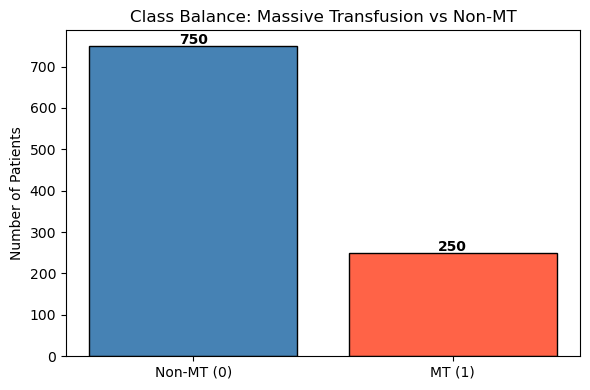

In [11]:
# Class balance: 

fig, ax = plt.subplots(figsize=(6, 4))

# Count MT vs non-MT
counts = df['MT'].value_counts()
ax.bar(['Non-MT (0)', 'MT (1)'], counts.values, color=['steelblue', 'tomato'], edgecolor='black')

# Add count labels on bars
for i, v in enumerate(counts.values):
    ax.text(i, v + 5, str(v), ha='center', fontweight='bold')

ax.set_title('Class Balance: Massive Transfusion vs Non-MT')
ax.set_ylabel('Number of Patients')
plt.tight_layout()
plt.show()

In [12]:
num_features = ['Age', 'Systolic_BP_mmHg', 'Heart_Rate_BPM', 'Respiratory_Rate_BPM',
                'GCS_Score', 'Lactate_mmol_L', 'Arterial_Base_Excess', 
                'Time_to_Hospital_min', 'Shock_Index', 'Units_Transfused']

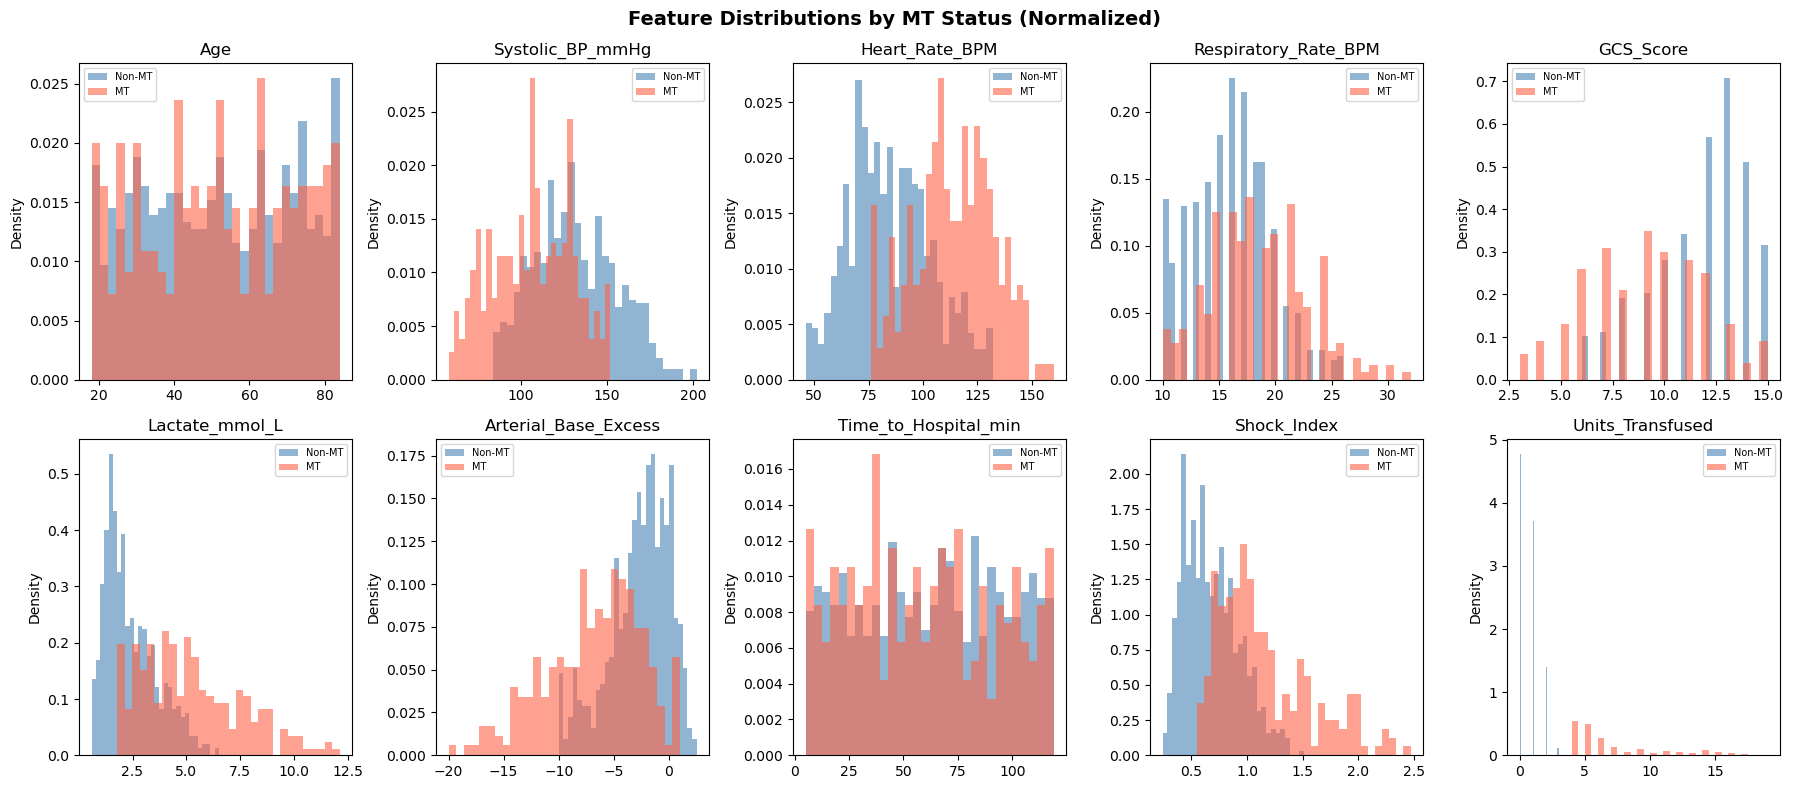

In [13]:
# Distributions of numerical features:

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(num_features):
    # density=True normalizes both groups to the same scale
    axes[i].hist(df[df['MT'] == 0][col], bins=30, alpha=0.6, 
                 color='steelblue', label='Non-MT', density=True)
    axes[i].hist(df[df['MT'] == 1][col], bins=30, alpha=0.6, 
                 color='tomato', label='MT', density=True)
    axes[i].set_title(col)
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=7)

plt.suptitle('Feature Distributions by MT Status (Normalized)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

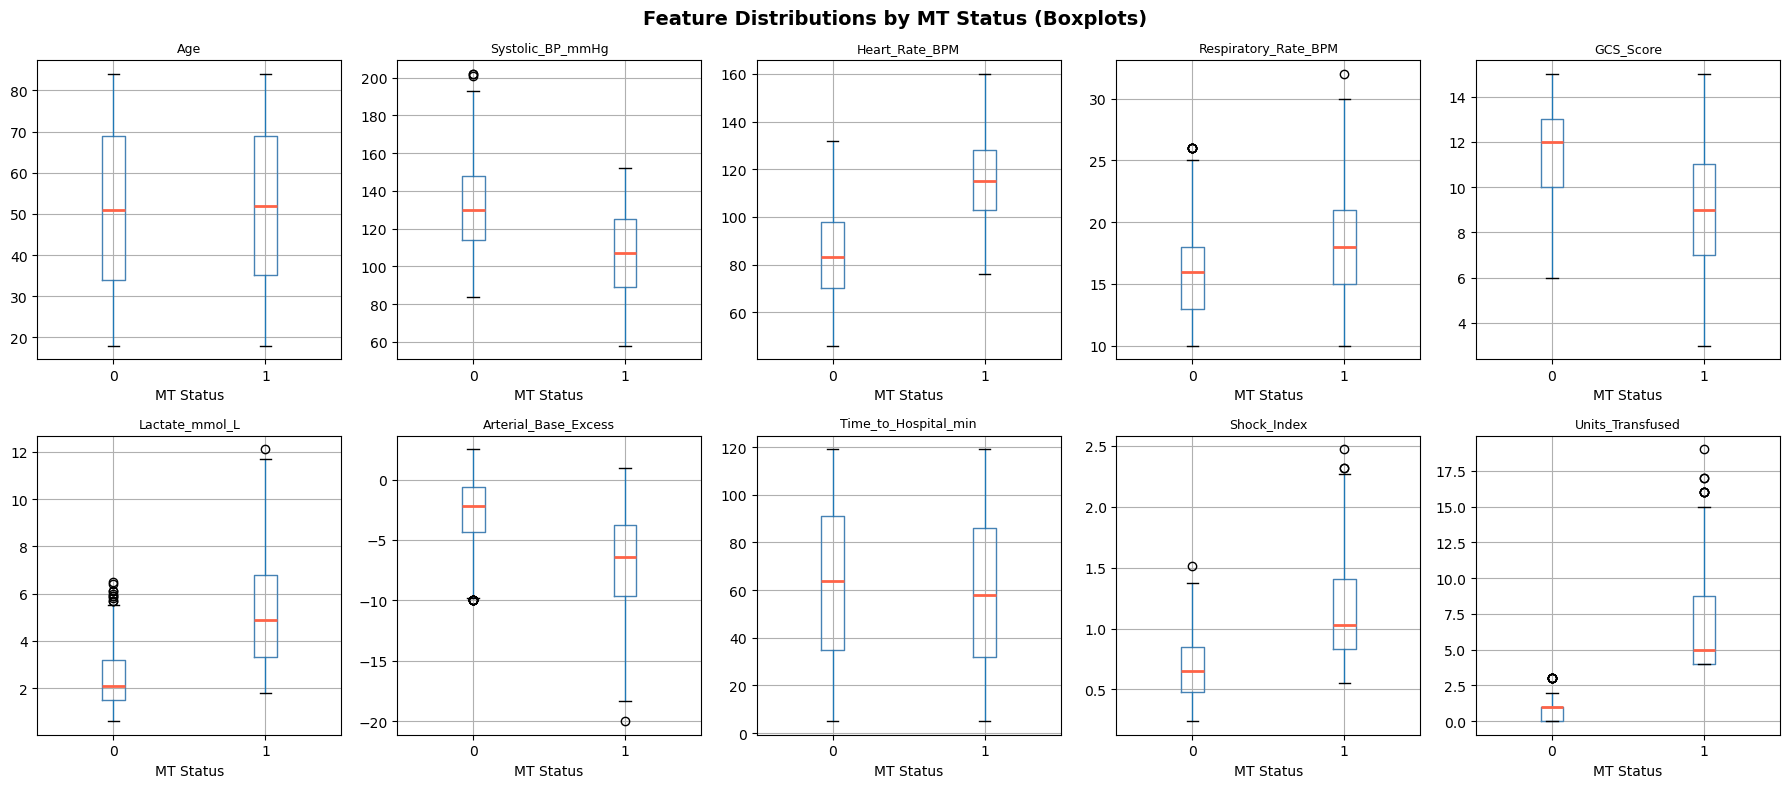

In [14]:
# Boxplots by MT status:

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(num_features):
    # Boxplot grouped by MT status
    df.boxplot(column=col, by='MT', ax=axes[i], 
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='tomato', linewidth=2))
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('MT Status')
    axes[i].set_ylabel('')

plt.suptitle('Feature Distributions by MT Status (Boxplots)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

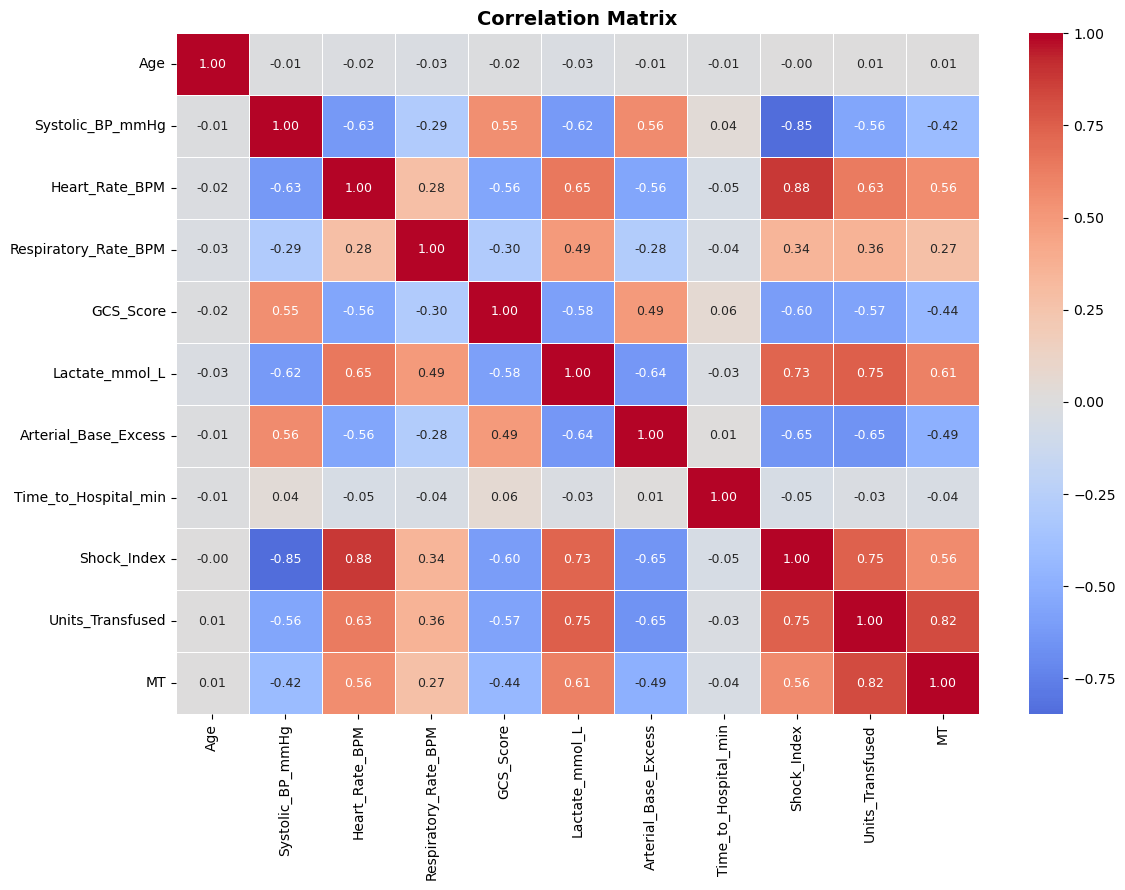

In [15]:
# Correlation matrix:

fig, ax = plt.subplots(figsize=(12, 9))

# Compute correlation matrix for numerical features + target
corr_cols = num_features + ['MT']
corr = df[corr_cols].corr()

# Plot heatmap
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax, annot_kws={'size': 9})

ax.set_title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

C:\Users\yulia\AppData\Local\Temp\ipykernel_18644\240255339.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot([data_0, data_1], labels=['Non-MT', 'MT'], patch_artist=True)


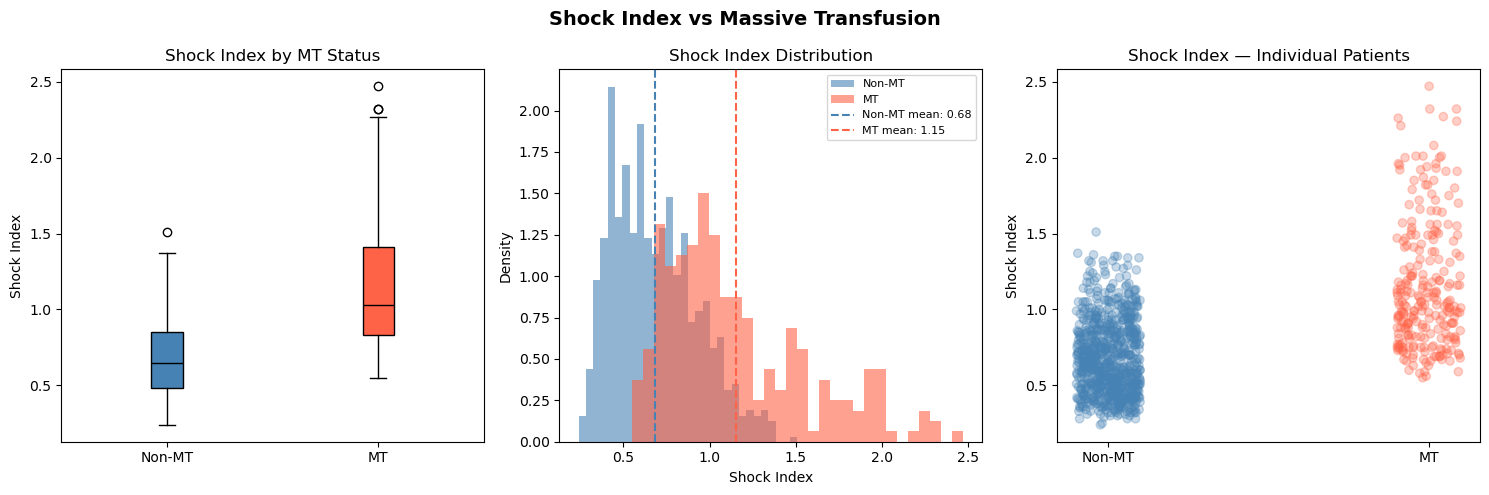

In [16]:
# Shock index VS MT: 

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Boxplot SI by MT
data_0 = df[df['MT'] == 0]['Shock_Index']
data_1 = df[df['MT'] == 1]['Shock_Index']
bp = axes[0].boxplot([data_0, data_1], labels=['Non-MT', 'MT'], patch_artist=True)
bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][1].set_facecolor('tomato')
for median in bp['medians']:
    median.set_color('black')
axes[0].set_title('Shock Index by MT Status')
axes[0].set_ylabel('Shock Index')

# 2. Distribution (density)
axes[1].hist(data_0, bins=30, alpha=0.6, color='steelblue', label='Non-MT', density=True)
axes[1].hist(data_1, bins=30, alpha=0.6, color='tomato', label='MT', density=True)
axes[1].axvline(data_0.mean(), color='steelblue', linestyle='--', label=f'Non-MT mean: {data_0.mean():.2f}')
axes[1].axvline(data_1.mean(), color='tomato', linestyle='--', label=f'MT mean: {data_1.mean():.2f}')
axes[1].set_title('Shock Index Distribution')
axes[1].set_xlabel('Shock Index')
axes[1].set_ylabel('Density')
axes[1].legend(fontsize=8)

# 3. Strip plot - individual patients
jitter = np.random.uniform(-0.1, 0.1, size=len(df))
axes[2].scatter(df['MT'] + jitter, df['Shock_Index'], 
                alpha=0.3, c=df['MT'].map({0: 'steelblue', 1: 'tomato'}))
axes[2].set_xticks([0, 1])
axes[2].set_xticklabels(['Non-MT', 'MT'])
axes[2].set_title('Shock Index — Individual Patients')
axes[2].set_ylabel('Shock Index')

plt.suptitle('Shock Index vs Massive Transfusion', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

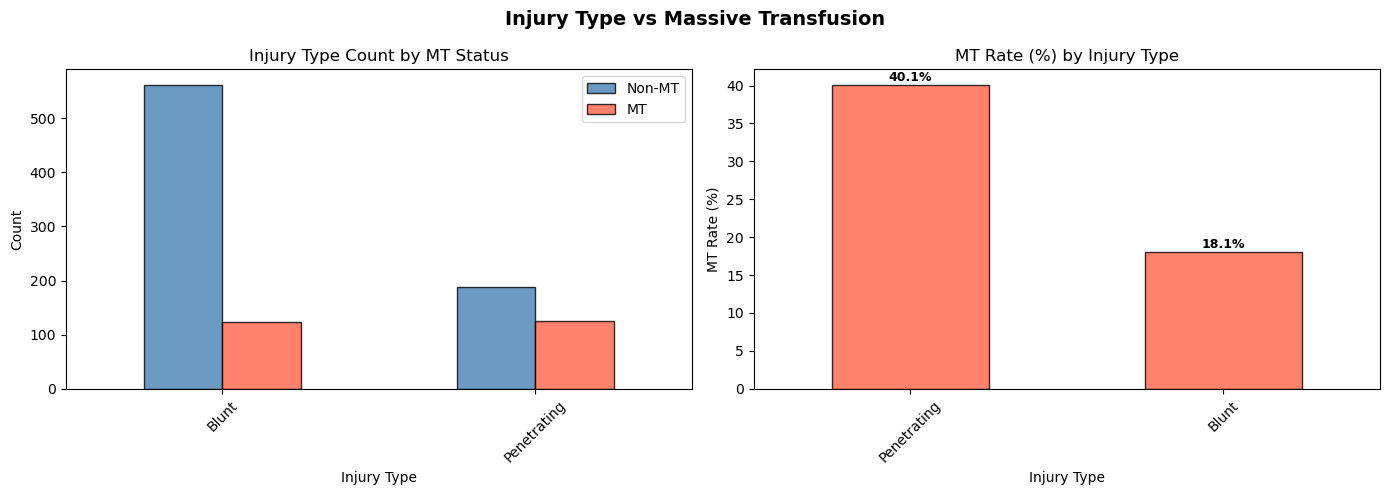

In [17]:
# Injury type VS MT:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Injury Type distribution by MT
injury_mt = df.groupby(['Injury_Type', 'MT']).size().unstack(fill_value=0)
injury_mt.plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato'], 
               edgecolor='black', alpha=0.8)
axes[0].set_title('Injury Type Count by MT Status')
axes[0].set_xlabel('Injury Type')
axes[0].set_ylabel('Count')
axes[0].legend(['Non-MT', 'MT'])
axes[0].tick_params(axis='x', rotation=45)

# 2. MT rate per Injury Type
mt_rate = df.groupby('Injury_Type')['MT'].mean() * 100
mt_rate.sort_values(ascending=False).plot(kind='bar', ax=axes[1], 
                                           color='tomato', edgecolor='black', alpha=0.8)
axes[1].set_title('MT Rate (%) by Injury Type')
axes[1].set_xlabel('Injury Type')
axes[1].set_ylabel('MT Rate (%)')
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(mt_rate.sort_values(ascending=False)):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Injury Type vs Massive Transfusion', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

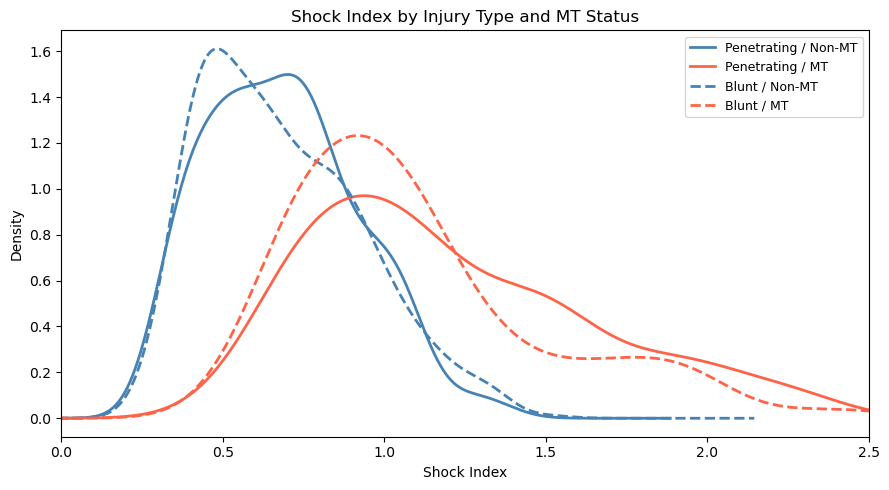

In [18]:
# SI + Injury Type + MT Status:

fig, ax = plt.subplots(figsize=(9, 5))

# Define styles for each group
groups = [
    ('Penetrating', 0, 'steelblue',  '-'),
    ('Penetrating', 1, 'tomato',     '-'),
    ('Blunt',       0, 'steelblue',  '--'),
    ('Blunt',       1, 'tomato',     '--'),
]

for injury, mt, color, linestyle in groups:
    subset = df[(df['Injury_Type'] == injury) & (df['MT'] == mt)]['Shock_Index']
    label = f'{injury} / {"MT" if mt else "Non-MT"}'
    subset.plot.kde(ax=ax, color=color, linestyle=linestyle, linewidth=2, label=label)

ax.set_title('Shock Index by Injury Type and MT Status')
ax.set_xlabel('Shock Index')
ax.set_ylabel('Density')
ax.set_xlim(0, 2.5)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()